# Checkpoint 2 – Parking-search ABM

This notebook shows the current working model and a **preliminary** parameter experiment for Checkpoint 2.

**Primary research question:** Under what combinations of vehicle arrival rate, average parking duration, and entry-control threshold does a near-capacity car park develop persistent search congestion?

**Secondary question:** Can entry control reduce or delay this congestion without mainly moving the waiting to the entrance?


## Current model

The model is a simplified agent-based car park with a one-way loop and finite parking spaces. Cars can arrive, wait outside, search, perform a two-step parking manoeuvre, remain parked for a stochastic duration, and later leave.

The main adjustable variables are `arrival_prob`, `mean_parking_duration`, `entry_control`, and `entry_threshold`.


In [30]:
import sys
from pathlib import Path

repo_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.model import ParkingModel
from src.experiments import run_condition, run_initial_sweep
from utils.plots import (
    read_csv_rows,
    plot_search_and_waiting_timeseries,
    plot_late_searching_by_arrival,
    plot_entry_control_tradeoff,
)


## Experiment plan

For the first Checkpoint 2 sweep we use exploratory model values:

- arrival probability: **0.10, 0.30, 0.50**;
- mean parking duration: **10, 20, 30 simulation steps**;
- entry control: **off**, or **on at an occupancy threshold of 0.80**;
- **10 random seeds** per condition;
- **400 simulation steps** per run.

This gives 18 parameter conditions and 180 runs. These values are used to explore model behaviour; they are not claimed to be measured UWA values.


## How we look for persistent congestion

We do not assume a sharp tipping point exists. For this preliminary analysis we use `late_mean_searching`: the mean number of cars searching during the final 20% of a run. We also record how often searching clears to zero, outside waiting, waiting times for cars that successfully park, and unfinished cars at the end.


In [31]:
data_dir = repo_root / 'data'
summary_path = data_dir / 'initial_sweep_summary.csv'

if not summary_path.exists():
    run_initial_sweep(output_dir=data_dir)

summary_rows = read_csv_rows(summary_path)
len(summary_rows)


18

## Example 1: a condition where searching normally clears

This example uses low arrival probability and short average parking duration.


In [32]:
clear_result, clear_model = run_condition(
    arrival_prob=0.10,
    mean_parking_duration=10,
    entry_control=False,
    seed=2,
    steps=400,
    return_model=True,
)
clear_result


{'seed': 2,
 'arrival_prob': 0.1,
 'mean_parking_duration': 10,
 'entry_control': False,
 'entry_threshold': 0.8,
 'steps': 400,
 'mean_searching_cars': 0.2425,
 'max_searching_cars': 3,
 'late_mean_searching': 0.175,
 'search_clear_fraction': 0.7925,
 'mean_waiting_outside': 0.01,
 'late_mean_waiting_outside': 0.025,
 'final_waiting_outside': 0,
 'mean_occupancy': 0.09479166666666666,
 'mean_blocked_by_parking': 0.0075,
 'mean_search_time': 4.714285714285714,
 'mean_outside_waiting_time': 0.11428571428571428,
 'mean_total_waiting_time': 4.828571428571428,
 'successful_parking_count': 35,
 'generated_arrivals': 36,
 'completion_fraction': 0.9722222222222222,
 'unfinished_vehicle_count': 1,
 'final_searching': 1,
 'final_parking_manoeuvre': 0}

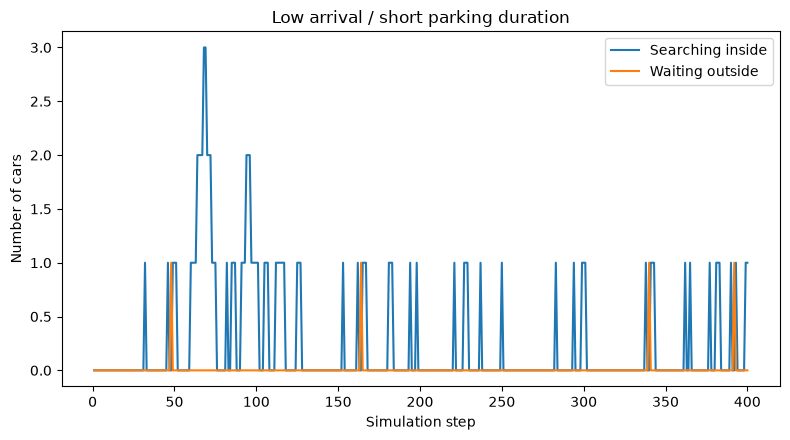

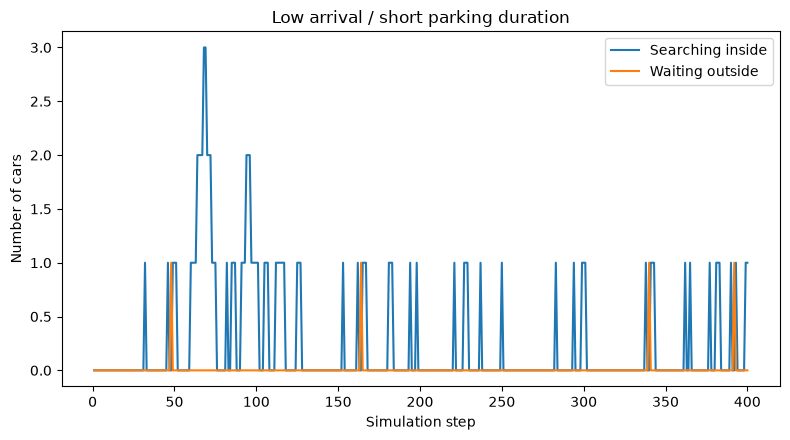

In [33]:
plot_search_and_waiting_timeseries(
    clear_model,
    title='Low arrival / short parking duration',
)


## Example 2: a condition with persistent-looking search congestion

With higher arrival probability and longer parking duration, searching remains much higher late in the run and the model clears much less often.


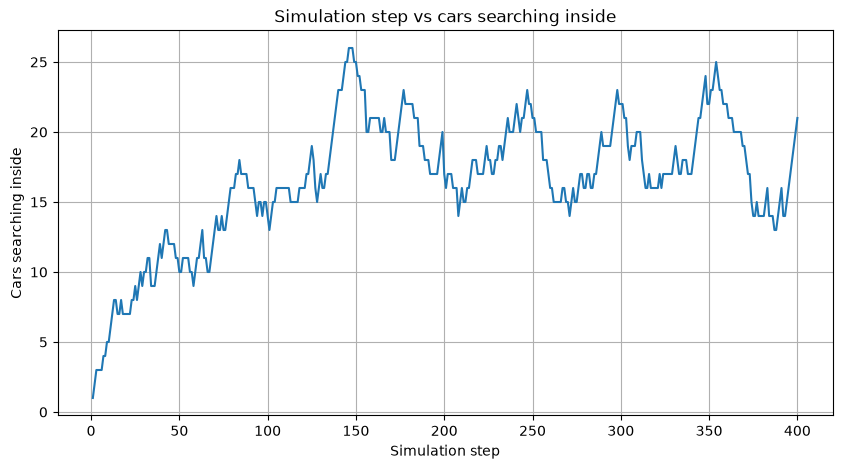

In [34]:
import matplotlib.pyplot as plt

times = [row["time"] for row in heavy_model.step_results]

searching_inside = [
    row["searching_inside"]
    for row in heavy_model.step_results
]

plt.figure(figsize=(10, 5))
plt.plot(times, searching_inside)

plt.xlabel("Simulation step")
plt.ylabel("Cars searching inside")
plt.title("Simulation step vs cars searching inside")
plt.grid(True)
plt.show() 

In [35]:
heavy_result, heavy_model = run_condition(
    arrival_prob=0.50,
    mean_parking_duration=30,
    entry_control=False,
    seed=2,
    steps=400,
    return_model=True,
)
heavy_result


{'seed': 2,
 'arrival_prob': 0.5,
 'mean_parking_duration': 30,
 'entry_control': False,
 'entry_threshold': 0.8,
 'steps': 400,
 'mean_searching_cars': 16.555,
 'max_searching_cars': 26,
 'late_mean_searching': 18.1625,
 'search_clear_fraction': 0.0,
 'mean_waiting_outside': 16.4775,
 'late_mean_waiting_outside': 33.225,
 'final_waiting_outside': 38,
 'mean_occupancy': 0.86875,
 'mean_blocked_by_parking': 2.8625,
 'mean_search_time': 41.979166666666664,
 'mean_outside_waiting_time': 25.541666666666668,
 'mean_total_waiting_time': 67.52083333333333,
 'successful_parking_count': 144,
 'generated_arrivals': 203,
 'completion_fraction': 0.7093596059113301,
 'unfinished_vehicle_count': 59,
 'final_searching': 21,
 'final_parking_manoeuvre': 0}

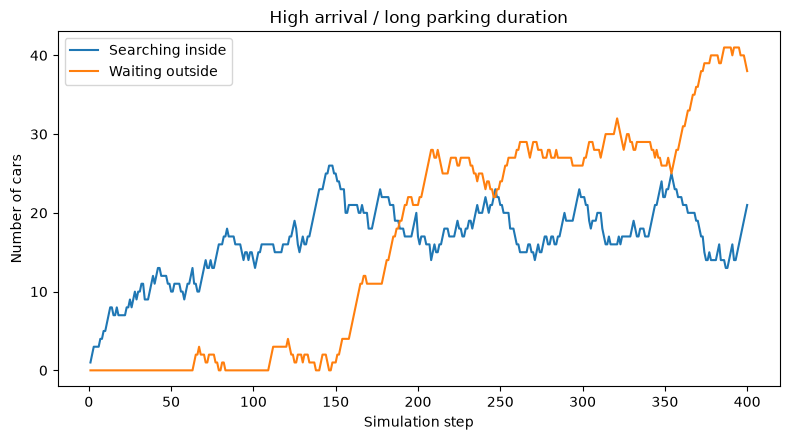

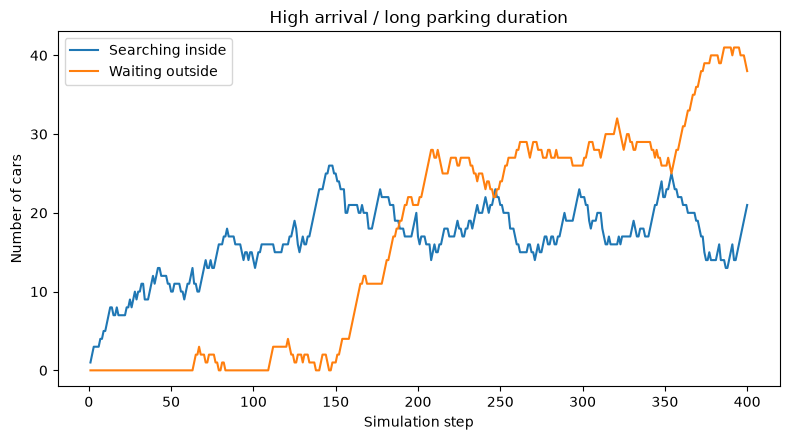

In [36]:
plot_search_and_waiting_timeseries(
    heavy_model,
    title='High arrival / long parking duration',
)


## Parameter interaction

The next two figures compare the mean late-run searching level across the full initial grid. Each point is averaged over 10 random seeds.


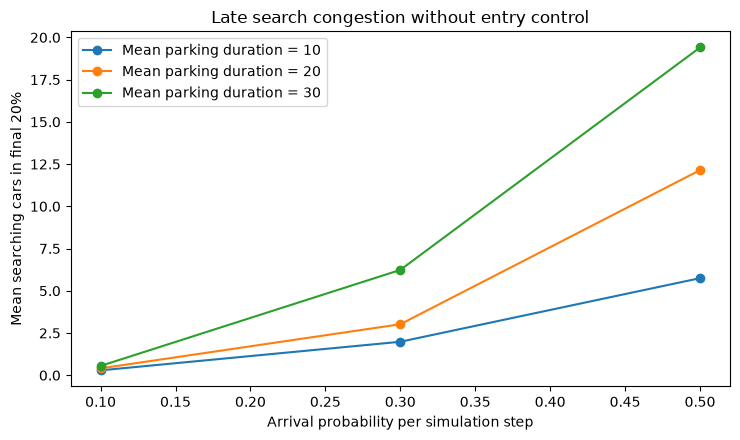

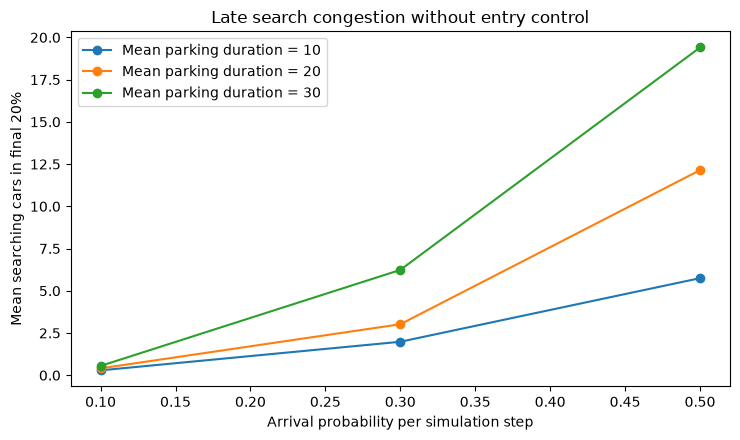

In [37]:
plot_late_searching_by_arrival(summary_rows, entry_control=False)


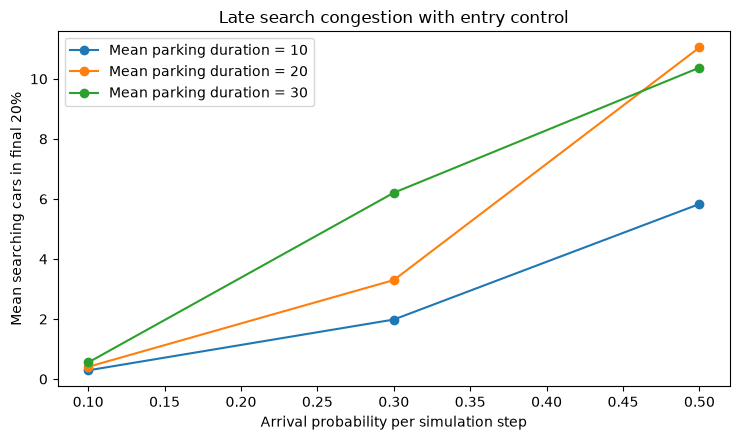

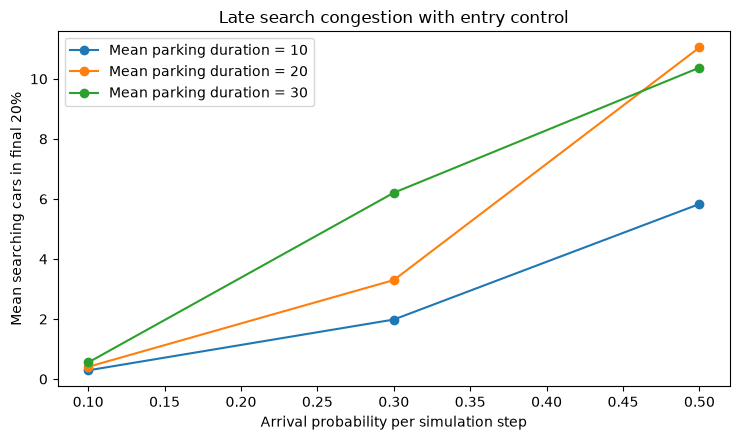

In [38]:
plot_late_searching_by_arrival(summary_rows, entry_control=True)


## Entry-control trade-off

For a demanding condition (`arrival_prob=0.50`, `mean_parking_duration=30`), entry control reduces the average number of cars searching inside, but more cars wait outside. This is why we should not judge the policy only from internal congestion.


In [39]:
no_control_result = run_condition(
    arrival_prob=0.50,
    mean_parking_duration=30,
    entry_control=False,
    seed=2,
    steps=400,
)

with_control_result = run_condition(
    arrival_prob=0.50,
    mean_parking_duration=30,
    entry_control=True,
    entry_threshold=0.80,
    seed=2,
    steps=400,
)

print("Without entry control:")
print("Mean total waiting time =", no_control_result["mean_total_waiting_time"])

print()

print("With entry control:")
print("Mean total waiting time =", with_control_result["mean_total_waiting_time"])

Without entry control:
Mean total waiting time = 67.52083333333333

With entry control:
Mean total waiting time = 86.03174603174604


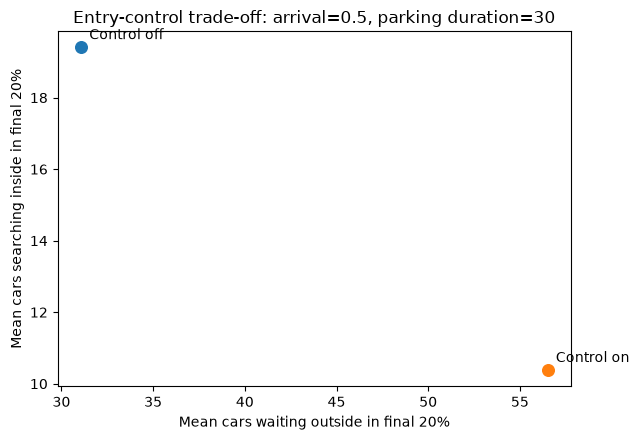

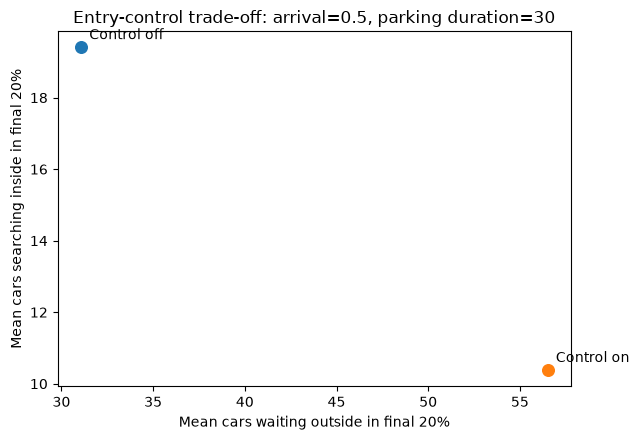

In [40]:
plot_entry_control_tradeoff(
    summary_rows,
    arrival_prob=0.50,
    mean_parking_duration=30,
)


## Preliminary observations

- Low arrival probability produces repeated clearing in the tested cases.
- Increasing arrival probability and average parking duration increases late-run searching and reduces how often searching clears.
- In the demanding example, entry control reduces internal searching but increases outside waiting, showing the expected trade-off.
- These results are preliminary. They show useful model behaviour, but they do not yet prove a sharp tipping point.


## Current limitations / next steps

- simulation steps are not calibrated to real time;
- the layout is a simplified loop rather than a real UWA car park;
- parking duration uses an exponential distribution as a modelling assumption;
- at most one new arrival is generated per step;
- departing cars disappear instead of merging back into the road;
- outside waiting can be caused by the occupied entrance cell as well as by entry control;
- waiting-time means only include cars that successfully park before the run ends, so unfinished-car counts must also be considered;
- later experiments should refine the parameter range around any apparent transition and test sensitivity to assumptions such as parking-manoeuvre duration.
